In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  

display(X)
display(y)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


### Questão 1-


In [2]:
from sklearn.preprocessing import MinMaxScaler

# Modificando o conjunto de dados de qualidade do vinho para as três classes sugeridas.
new_y = y['quality'].apply(
    lambda value: "ruim" if value <= 5
    else "medio" if value <= 7
    else "bom"
)

display(new_y)

scaler = MinMaxScaler()

# Normalizando os demais dados com o MinMaxScaler
X_normalized = scaler.fit_transform(X)

display(X_normalized)

0        ruim
1        ruim
2        ruim
3       medio
4        ruim
        ...  
6492    medio
6493     ruim
6494    medio
6495    medio
6496    medio
Name: quality, Length: 6497, dtype: str

array([[0.29752066, 0.41333333, 0.        , ..., 0.6124031 , 0.19101124,
        0.20289855],
       [0.33057851, 0.53333333, 0.        , ..., 0.37209302, 0.25842697,
        0.26086957],
       [0.33057851, 0.45333333, 0.02409639, ..., 0.41860465, 0.24157303,
        0.26086957],
       ...,
       [0.2231405 , 0.10666667, 0.11445783, ..., 0.20930233, 0.13483146,
        0.20289855],
       [0.14049587, 0.14      , 0.18072289, ..., 0.48062016, 0.08988764,
        0.69565217],
       [0.18181818, 0.08666667, 0.22891566, ..., 0.41860465, 0.05617978,
        0.55072464]], shape=(6497, 11))

O motivo da normalização ser uma etapa obrigatória para o algoritmo KNN...

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    new_y,
    test_size=0.2,
    stratify=new_y,
    random_state=42
)


print("Treino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (5197, 11)
Teste: (1300, 11)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Valores de k
k_values = [1, 3, 5, 7, 11]

mean_scores = []

# Teste dos valores de K
for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    # Validação cruzada com 5 folds
    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    # Média da acurácia
    mean_scores.append(scores.mean())

    print(f"k = {k}")
    print(f"Acurácias: {scores}")
    print(f"Média: {scores.mean():.4f}")

# Melhor k
best_k = k_values[mean_scores.index(max(mean_scores))]

print(f"Melhor valor de k: {best_k}")


k = 1
Acurácias: [0.71923077 0.72211538 0.75553417 0.75264678 0.74975938]
Média: 0.7399
k = 3
Acurácias: [0.70096154 0.68942308 0.71318576 0.71607315 0.73243503]
Média: 0.7104
k = 5
Acurácias: [0.71730769 0.70865385 0.72569779 0.72281039 0.7333975 ]
Média: 0.7216
k = 7
Acurácias: [0.725      0.71346154 0.72088547 0.72954764 0.71799808]
Média: 0.7214
k = 11
Acurácias: [0.71826923 0.7125     0.72473532 0.72473532 0.72666025]
Média: 0.7214
Melhor valor de k: 1


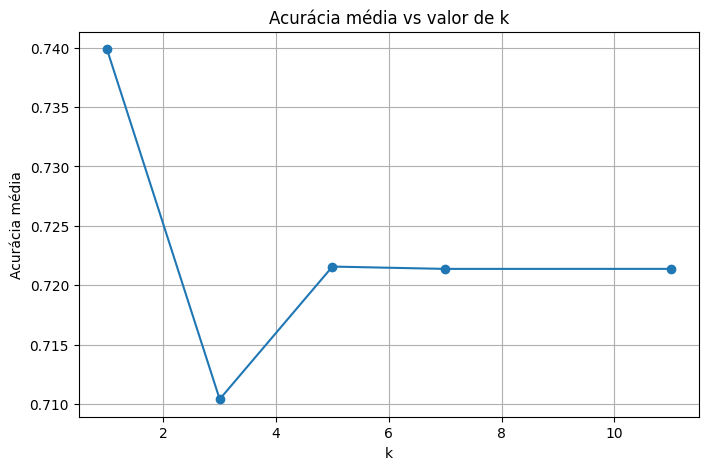

In [7]:
plt.figure(figsize=(8,5))
plt.plot(k_values, mean_scores, marker='o')
plt.title("Acurácia média vs valor de k")
plt.xlabel("k")
plt.ylabel("Acurácia média")
plt.grid(True)
plt.show()

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:\n")
print(confusion_matrix(y_test, y_pred))

Acurácia: 0.7607692307692308
              precision    recall  f1-score   support

         bom       0.48      0.50      0.49        40
       medio       0.80      0.80      0.80       783
        ruim       0.72      0.71      0.72       477

    accuracy                           0.76      1300
   macro avg       0.67      0.67      0.67      1300
weighted avg       0.76      0.76      0.76      1300


Matriz de Confusão:

[[ 20  20   0]
 [ 21 630 132]
 [  1 137 339]]
